The code runs for both checbyschev and fnn, but to be sure it is best to restart the kernel when changing feature maps

Before running, download and chang the file path for the reference values. Keep the r before the path or it gives error.

If it doesn't run, ask Gemini.

In [1]:
## Imports
import torch
import pennylane as qml
import matplotlib.pyplot as plt
from itertools import product
import datetime
import numpy as np
import os
import sys
import pandas as pd

torch.manual_seed(42)
torch.set_num_threads(30)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
## Constants
# QNet Parameter
N_WIRES = 4
N_LAYERS = 5

# FNN Basis Net
HIDDEN_LAYERS_FNN = 2
NEURONS_FNN = 6

# Domain Parameter
X_COLOC_POINTS = 50
Y_COLOC_POINTS = 25
BOUNDARY_SCALE = 10e1

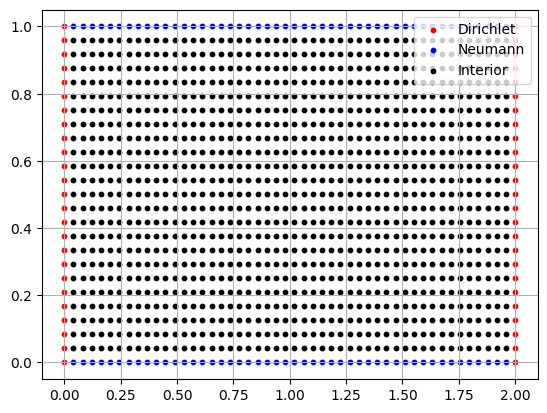

In [3]:
##  Generate Domain

# Generate Collocation Points
x = torch.linspace(0.0, 2.0, X_COLOC_POINTS)
y = torch.linspace(0.0, 1.0, Y_COLOC_POINTS)
input_domain = torch.tensor(list(product(x, y)))

dir_boundary_mask = (input_domain[:, 0] == 0.0) | (input_domain[:, 0] == 2.0)
dir_boundary_colloc = input_domain[dir_boundary_mask]

# Neumann Boundary
neu_boundary_mask = (input_domain[:, 1] == 0.0) | (input_domain[:, 1] == 1.0)
neu_boundary_colloc = input_domain[neu_boundary_mask & ~dir_boundary_mask] 

# Combined Boundary Mask
boundary_mask = dir_boundary_mask | neu_boundary_mask

# Filter out boundary points from domain_colloc
interior_colloc = input_domain[~boundary_mask]

input_domain = input_domain.clone().detach().requires_grad_(True).to(device)
dir_boundary_colloc = dir_boundary_colloc.clone().detach().requires_grad_(True).to(device)
neu_boundary_colloc = neu_boundary_colloc.clone().detach().requires_grad_(True).to(device)
interior_colloc = interior_colloc.clone().detach().requires_grad_(True).to(device)

domain_bounds = torch.tensor([[0.0, 0.0], [2.0, 1.0]], device=device)

# # Plot domain
plt.scatter(dir_boundary_colloc[:,0].detach().cpu(),dir_boundary_colloc[:,1].detach().cpu(), c="r", label="Dirichlet", s=10)
plt.scatter(neu_boundary_colloc[:,0].detach().cpu(),neu_boundary_colloc[:,1].detach().cpu(), c="blue", label="Neumann", s=10)
plt.scatter(interior_colloc[:,0].detach().cpu(),interior_colloc[:,1].detach().cpu(), c="black", label="Interior", s=10)
plt.grid()
plt.legend()
plt.show()


In [4]:
## Create the Model
map = "Chebyschev_tower" ## CHANGE MAPPING HERE


# Define QPINN
@qml.qnode(qml.device("default.qubit", wires=N_WIRES), interface="torch")
def circuit(x, basis = None):

    # Embedding
    if map == "Chebyschev_tower":
        for w in range(N_WIRES):
            if w % 2 == 0:
                # Scale x slightly to avoid periodicity issues in simple maps
                qml.RY(torch.arccos(x[0]) * (w + 1), wires=w) 
            else:
                qml.RY(torch.arccos(x[1]) * (w + 1), wires=w)

    elif map == "fnn_map":
        for i in range(N_WIRES):
            if i % 2 == 0:
                qml.RY(basis[i] * x[0], wires=i)
            else:
                qml.RY(basis[i] * x[1], wires=i)
    
    # Variational ansatz
    for i in range(N_LAYERS):
        for j in range(N_WIRES):
            qml.RZ(theta[i,j,0], wires=j)
            qml.RX(theta[i,j,1], wires=j)
            qml.RZ(theta[i,j,2], wires=j)
    
        for j in range(N_WIRES // 2):
                qml.CNOT(wires=[2*j,2*j+1]) # first layer: even wires

        for j in range((N_WIRES - 1) // 2):
                qml.CNOT(wires=[2*j+1,2*j+2]) # second layer: odd wires

    # Cost Function
    return qml.expval(qml.sum(*[qml.PauliZ(i) for i in range(N_WIRES)]))

# Define FNN for the basis
class FNN(torch.nn.Module):
    def __init__(self, n_hidden_layers, branch_width, output_dim=N_WIRES):
        super().__init__()

        self.n_hidden_layers = n_hidden_layers
        self.branch_width = branch_width
        self.layers = torch.nn.ModuleList()
        self.layers.append(torch.nn.Linear(2, branch_width))
        for i in range(n_hidden_layers -1):
            self.layers.append(torch.nn.Linear(branch_width, branch_width))
        self.layers.append(torch.nn.Linear(branch_width, output_dim))

    def forward(self, x):
        for i in range(self.n_hidden_layers):
            x = torch.tanh(self.layers[i](x))
        x = self.layers[self.n_hidden_layers](x)
        return x

def model(x):
    # Rescale input to [-0.95, 0.95]       
    x_rescaled = 1.9 * (x - domain_bounds[0])/(domain_bounds[1] - domain_bounds[0]) - 0.95
    if map == 'Chebyschev_tower':
        return circuit(x_rescaled.T)
    else:
        return circuit(x_rescaled.T, basisNet(x_rescaled).T)

def get_n_params(fnn_model):
    pp=0
    for p in list(fnn_model.parameters()):
        print(p.size())
        nn=1
        for s in list(p.size()):
            nn = nn*s
        pp += nn
    return pp

<class 'numpy.ndarray'>
()


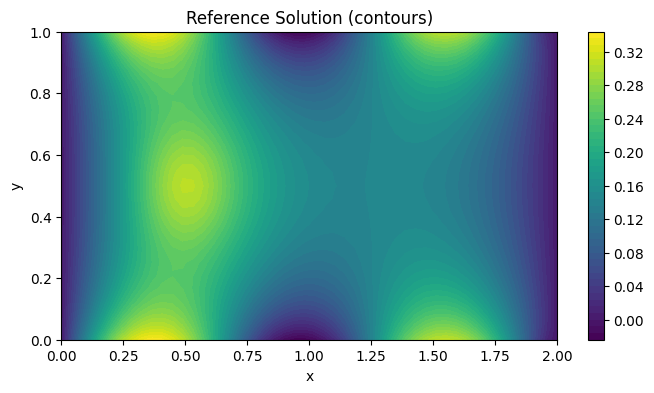

In [5]:
#Import reference solution

obj = np.load(
    r"C:\Users\tiago\Downloads\poisson_reference_solution.npy",
    allow_pickle=True
)

print(type(obj))
print(obj.shape)

u_interp = obj.item()

def reference_solution(data):
    output = np.zeros(data.shape[0])
    for i in range(data.shape[0]):
        output[i] = u_interp([data[i, 0], data[i, 1]]).squeeze()
    return output

reference_values = torch.tensor(reference_solution(input_domain.detach().cpu()), device=device)

# Move to CPU and numpy
x = input_domain[:, 0].detach().cpu().numpy()
y = input_domain[:, 1].detach().cpu().numpy()
u = reference_values.detach().cpu().numpy()

# Get unique grid points
x_unique = np.unique(x)
y_unique = np.unique(y)

# Reshape u to 2D grid for plotting
X, Y = np.meshgrid(x_unique, y_unique)

# u must be reshaped according to y,x ordering
U_ref = u.reshape(len(x_unique), len(y_unique)).T  # transpose might be needed

plt.figure(figsize=(8,4))
cp = plt.contourf(X, Y, U_ref, levels=50, cmap='viridis')
plt.colorbar(cp)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Reference Solution (contours)')
plt.show()



In [6]:
## Define the problem
def source_term(x):
    return 10 * torch.exp(-((x[:, 0] - 0.5) ** 2 + (x[:, 1] - 0.5) ** 2) / 0.02)

def neu_boundary_term(x):
    return torch.sin(5 * x[:, 0])

def dir_loss_fnc(model):
    u_dir = model(dir_boundary_colloc)
    return torch.mean(u_dir**2)

def neu_loss_fnc(model):
    u_neu = model(neu_boundary_colloc)

    du_d = torch.autograd.grad(u_neu, neu_boundary_colloc, grad_outputs=torch.ones_like(u_neu), create_graph=True)[0]
    du_dy = du_d[:, 1]

    # Flip signs for first values, since they have to be outward facing relative to the domain
    du_dy[::2] *= -1.0

    g = neu_boundary_term(neu_boundary_colloc)
    return torch.mean((du_dy - g) ** 2)

def pde_loss_fnc(model):
    u = model(interior_colloc)
    f = source_term(interior_colloc)

    grad_out = torch.ones_like(u)
    du_d = torch.autograd.grad(u, interior_colloc, grad_outputs=grad_out, create_graph=True)[0]
    du_dx = du_d[:, 0]
    du_dy = du_d[:, 1]

    du_dxd = torch.autograd.grad(du_dx, interior_colloc, grad_outputs=grad_out, create_graph=True)[0]
    du_dxdx = du_dxd[:, 0]

    du_dyd = torch.autograd.grad(du_dy, interior_colloc, grad_outputs=grad_out, create_graph=True)[0]
    du_dydy = du_dyd[:, 1]

    pde_res = -du_dxdx - du_dydy - f
    return torch.mean(pde_res**2)


def loss_fnc():
    dir_loss = dir_loss_fnc(model)
    neu_loss = neu_loss_fnc(model)
    pde_loss = pde_loss_fnc(model)
    return BOUNDARY_SCALE * (dir_loss + neu_loss) + pde_loss


def compute_MSE_ref(model):
    prediction = model(input_domain)
    return torch.mean((prediction-reference_values)**2).detach().cpu().item()

def compute_lmax_norm(model):
    prediction = model(input_domain)
    return torch.max(torch.abs(prediction-reference_values)).detach().cpu().item()


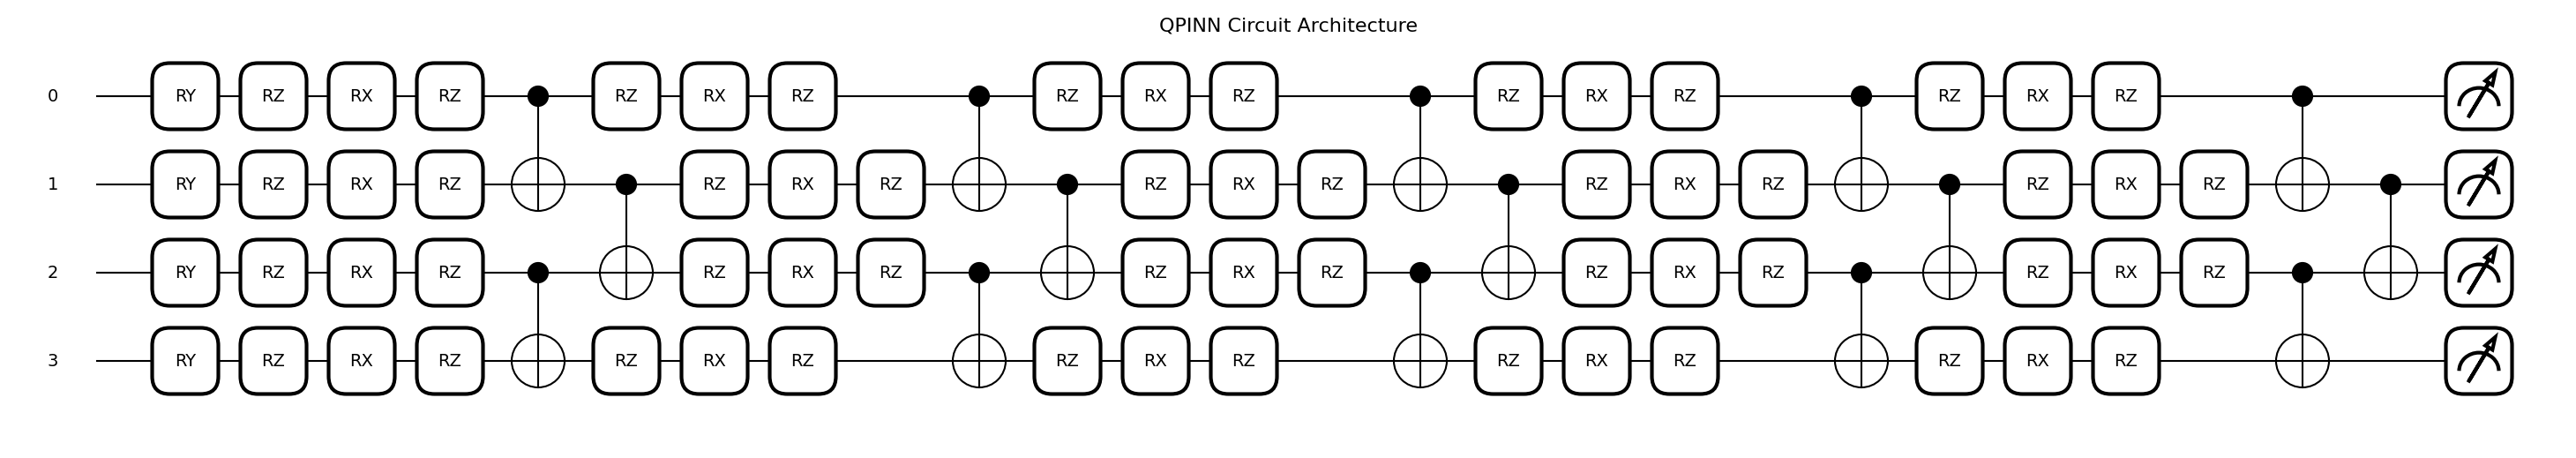

Number of trainable parameters in QPINN:  60
QPINN: Epoch 0, Loss: 49.88017800578924
QPINN: Epoch 1, Loss: 13.17994865609905
QPINN: Epoch 2, Loss: 8.577191229844445
QPINN: Epoch 3, Loss: 6.5481281527287685
QPINN: Epoch 4, Loss: 5.172347866567554
QPINN: Epoch 5, Loss: 4.534769917470985
QPINN: Epoch 6, Loss: 4.094631744297563
QPINN: Epoch 7, Loss: 3.921342484175807
QPINN: Epoch 8, Loss: 3.8696494705155224
QPINN: Epoch 9, Loss: 3.8260190516706754
QPINN: Epoch 10, Loss: 3.704338351611241
QPINN: Epoch 11, Loss: 3.589272393903268
QPINN: Epoch 12, Loss: 3.5457768831714307
QPINN: Epoch 13, Loss: 3.430341485276043
QPINN: Epoch 14, Loss: 3.3529250182514527
QPINN: Epoch 15, Loss: 3.2746791032078937
QPINN: Epoch 16, Loss: 3.193663900470706
QPINN: Epoch 17, Loss: 3.1563073446959646
QPINN: Epoch 18, Loss: 3.112928399460364
QPINN: Epoch 19, Loss: 3.088139577975247
QPINN: Epoch 20, Loss: 3.049038899172326
QPINN: Epoch 21, Loss: 3.043223575030254
QPINN: Epoch 22, Loss: 3.021341690562185
QPINN: Epoch 23

In [9]:
## Train the model
qpinn_data = []
pinn_data = []

for i in range(1):
    # Create initial parameters and BasisNet object
    theta = torch.rand(N_LAYERS, N_WIRES, 3, device=device, requires_grad=True)
    
    sample_x = torch.tensor([0.5, 0.5])
    sample_basis = torch.ones(N_WIRES) # Only needed if map == "fnn_map"

    # 2. Use qml.draw_mpl to create the visualization
    # This will render the embedding, the RZ-RX-RZ variational layers, and your custom CNOT pattern
    fig, ax = qml.draw_mpl(circuit)(sample_x, sample_basis)

    # 3. Optional: Customize the look
    fig.suptitle("QPINN Circuit Architecture", fontsize=16)
    plt.show()

    if map == 'Chebyschev_tower':
        opt = torch.optim.LBFGS([theta], line_search_fn="strong_wolfe")
    elif map == 'fnn_map':
        basisNet = FNN(2, 10).to(device)
        opt = torch.optim.LBFGS([theta, *basisNet.parameters()], line_search_fn="strong_wolfe")
    
    # Number of trainable parameters
    if map == 'Chebyschev_tower':
        print("Number of trainable parameters in QPINN: ", theta.flatten().shape[0])

    else:
        print("Number of trainable parameters in QPINN: ", get_n_params(basisNet) + theta.flatten().shape[0])


    loss_history_qpinn = []

    def closure():
        opt.zero_grad()
        l = loss_fnc()
        l.backward()
        return l
    
    for i in range(50):
        opt.step(closure)
        loss_history_qpinn.append(loss_fnc().item())
        print(f"QPINN: Epoch {i}, Loss: {loss_fnc().item()}")


    qpinn_data.append(loss_history_qpinn)

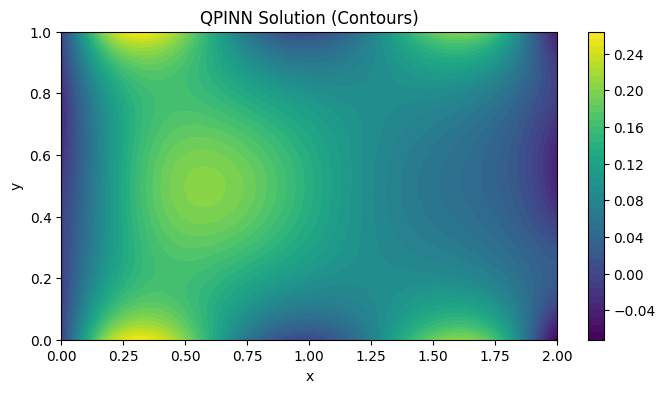

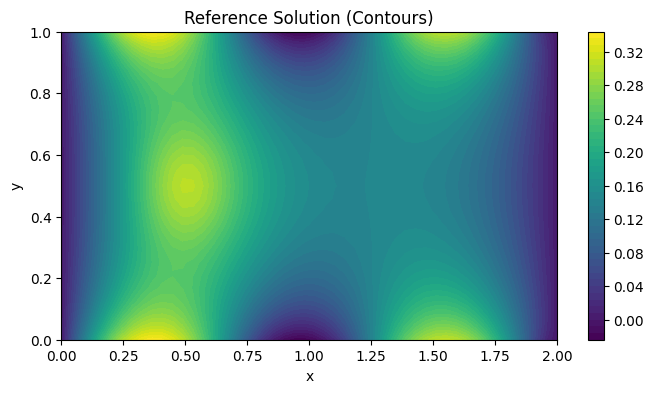

In [10]:
# Predict at the domain points
u_qpinn = model(input_domain)
u_qpinn = u_qpinn.detach().cpu().numpy()

x = input_domain[:, 0].detach().cpu().numpy()
y = input_domain[:, 1].detach().cpu().numpy()

x_unique = np.unique(x)
y_unique = np.unique(y)

X, Y = np.meshgrid(x_unique, y_unique)

# --- CORRECTION HERE ---
# 1. Reshape to (Nx, Ny) because data is ordered x-slow, y-fast
# 2. Transpose to (Ny, Nx) to match meshgrid (Y-axis rows, X-axis columns)
U = u_qpinn.reshape(len(x_unique), len(y_unique)).T 
# -----------------------

# Plot QPINN Solution
plt.figure(figsize=(8,4))
cp = plt.contourf(X, Y, U, levels=50, cmap='viridis')
plt.colorbar(cp)
plt.xlabel('x')
plt.ylabel('y')
plt.title('QPINN Solution (Contours)')
plt.show()

# Plot Reference Solution (for comparison)
plt.figure(figsize=(8,4))
cp = plt.contourf(X, Y, U_ref, levels=50, cmap='viridis')
plt.colorbar(cp)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Reference Solution (Contours)')
plt.show()


In [13]:
def plot_fnn_outputs(fnn_model):
    fnn_model.eval()
    with torch.no_grad():
        # Get angles for the whole domain
        # input_domain is (N_points, 2)
        # Rescale input exactly like you do in the model
        x_rescaled = 1.9 * (input_domain - domain_bounds[0])/(domain_bounds[1] - domain_bounds[0]) - 0.95
        
        angles = fnn_model(x_rescaled).cpu().numpy() # Shape (N_points, 4)

    x_phys = input_domain[:, 0].detach().cpu().numpy()
    y_phys = input_domain[:, 1].detach().cpu().numpy()
    x_u = np.unique(x_phys)
    y_u = np.unique(y_phys)
    X, Y = np.meshgrid(x_u, y_u)

    fig, axes = plt.subplots(1, N_WIRES, figsize=(18, 4))
    for i in range(N_WIRES):
        if map == "Chebyschev_tower":
            break
        # Reshape and transpose to match meshgrid (x-slow, y-fast)
        Z = angles[:, i].reshape(len(x_u), len(y_u)).T
        
        cp = axes[i].contourf(X, Y, Z, levels=50, cmap='twilight') # 'twilight' is good for angles/phases
        fig.colorbar(cp, ax=axes[i])
        axes[i].set_title(f"Wire {i} Input Angle")
        axes[i].set_xlabel("x")
        axes[i].set_ylabel("y")

    plt.tight_layout()
    plt.show()

# Call this after training
if map != 'Chebyshev_tower':
    plot_fnn_outputs(basisNet)

NameError: name 'basisNet' is not defined